# Notebook 05 — Machine Learning Models
**Project:** CompSpirit — Huawei Telecom Complaint Analytics & Network Intelligence Platform
**Deliverable:** D4 — ML Models

**Inputs:**
- `data/processed/feature_matrix.parquet`
- `data/processed/complaint_daily_agg.parquet`
- `data/processed/kpi_daily_agg.parquet`
- `data/processed/complaints_clean.parquet`
- `data/processed/kpi_clean.parquet`

**Outputs:**
- `models/anomaly/`        — Isolation Forest + scaler
- `models/prediction/`     — ARIMA / Prophet / XGBoost per region
- `models/classification/` — RF + XGBoost + SHAP values
- `models/clustering/`     — K-Means + DBSCAN + PCA
- `reports/figures/ml_*.png` — 10 charts

**Table of Contents**
1. Setup & Load
2. Anomaly Detection (Isolation Forest + Z-score/CUSUM)
3. Spike Prediction (ARIMA + Prophet + XGBoost)
4. Root Cause Classification (Random Forest + XGBoost + SHAP)
5. Customer Clustering (K-Means + DBSCAN)
6. D4 Summary & Checklist

## Cell 0 — Environment setup
FIX N1: portable root detection. FIX N6: scoped warnings. FIX N7: self-contained.

In [48]:
import sys
from pathlib import Path

def _find_project_root(start: Path, marker: str = "config") -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).is_dir():
            return parent
    raise RuntimeError(f"Cannot locate project root (looking for '{marker}/' dir).")

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import os
os.chdir(PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning,   module="pandas")
warnings.filterwarnings("ignore", category=FutureWarning,   module="sklearn")
warnings.filterwarnings("ignore", category=FutureWarning,   module="statsmodels")
warnings.filterwarnings("ignore", category=UserWarning,     module="statsmodels")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="darkgrid")
COLORS  = sns.color_palette("husl", 10)
FIGURES = "reports/figures"
os.makedirs(FIGURES, exist_ok=True)
for d in ["models/anomaly", "models/prediction",
          "models/classification", "models/clustering"]:
    os.makedirs(d, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"pandas       : {pd.__version__}")
print("Setup ✓")

Project root : C:\Users\c50057188\Desktop\PFE_Ouerghi
pandas       : 2.3.3
Setup ✓


## Cell 1 — Load datasets

In [49]:
feature_matrix   = pd.read_parquet("data/processed/feature_matrix.parquet")
complaint_agg    = pd.read_parquet("data/processed/complaint_daily_agg.parquet")
kpi_agg          = pd.read_parquet("data/processed/kpi_daily_agg.parquet")
complaints_clean = pd.read_parquet("data/processed/complaints_clean.parquet")
kpi_clean        = pd.read_parquet("data/processed/kpi_clean.parquet")

from src.processing.feature_engineering import time_series_split
X_train, X_test, y_train, y_test = time_series_split(feature_matrix)

print(f"feature_matrix   : {feature_matrix.shape}")
print(f"X_train / X_test : {X_train.shape} / {X_test.shape}")
print(f"y_train range    : {y_train.min():.0f} – {y_train.max():.0f}  mean={y_train.mean():.1f}")
if "complaint_spike_flag" in feature_matrix.columns:
    n_spike = int(feature_matrix["complaint_spike_flag"].sum())
    pct     = feature_matrix["complaint_spike_flag"].mean() * 100
    print(f"Spike days       : {n_spike} ({pct:.1f}%)")

2026-05-06 13:19:48.996 | INFO     | src.processing.feature_engineering:time_series_split:606 -   Train/test split: 6,470 train | 1,618 test | 135 features


feature_matrix   : (8088, 145)
X_train / X_test : (6470, 135) / (1618, 135)
y_train range    : 0 – 120  mean=2.9
Spike days       : 306 (3.8%)


## Cell 2 — Anomaly Detection

In [50]:
from src.models.anomaly_detector import AnomalyDetector

detector   = AnomalyDetector()
ad_results = detector.run(kpi_agg)

2026-05-06 13:19:49.048 | INFO     | src.models.anomaly_detector:run:103 - =======================================================
2026-05-06 13:19:49.056 | INFO     | src.models.anomaly_detector:run:104 - ANOMALY DETECTION
2026-05-06 13:19:49.059 | INFO     | src.models.anomaly_detector:run:105 - =======================================================
2026-05-06 13:19:49.060 | INFO     | src.models.anomaly_detector:run:107 - 
[1/3] Training Isolation Forest ...
2026-05-06 13:19:50.458 | INFO     | src.models.anomaly_detector:_run_isolation_forest:190 -   IF: 345 anomalies (4.3% of records)
2026-05-06 13:19:50.465 | INFO     | src.models.anomaly_detector:run:110 - 
[2/3] Running statistical control charts ...
2026-05-06 13:19:50.749 | INFO     | src.models.anomaly_detector:_run_statistical:259 -   Statistical: 913 anomalies (11.3% of records)
2026-05-06 13:19:50.754 | INFO     | src.models.anomaly_detector:run:113 - 
[3/3] Combining results ...
2026-05-06 13:19:50.903 | INFO     | src.

### 2a — Anomaly metrics

In [51]:
if_df = ad_results["isolation_forest"]
st_df = ad_results["statistical"]
cb_df = ad_results["combined"]
m     = ad_results["metrics"]

total = m.get("total_records", 1)
n_if  = m.get("if_anomalies",        0)
n_st  = m.get("stat_anomalies",      0)
n_uni = m.get("union_anomalies",     0)
n_con = m.get("consensus_anomalies", 0)

print("=== ANOMALY DETECTION — METRICS ===")
print(f"  Total records    : {total:>6,}")
print(f"  Isolation Forest : {n_if:>6,}  ({n_if/max(total,1):.1%})")
print(f"  Statistical      : {n_st:>6,}  ({n_st/max(total,1):.1%})")
print(f"  Combined (either): {n_uni:>6,}  ({n_uni/max(total,1):.1%})")
print(f"  Combined (both)  : {n_con:>6,}  ({n_con/max(total,1):.1%})")
print("\nTop anomaly regions:")
for region, count in m.get("top_anomaly_regions", {}).items():
    print(f"  {region:<15} {count}")

=== ANOMALY DETECTION — METRICS ===
  Total records    :  8,088
  Isolation Forest :    345  (4.3%)
  Statistical      :    913  (11.3%)
  Combined (either):  1,231  (15.2%)
  Combined (both)  :     27  (0.3%)

Top anomaly regions:
  Sousse Gouvernorat 98
  Mahdia Gouvernorat 92
  Kasserine Gouvernorat 83
  Kairouan Gouvernorat 77
  Sidi Bouzid Gouvernorat 72


### 2b — Anomaly score timeline

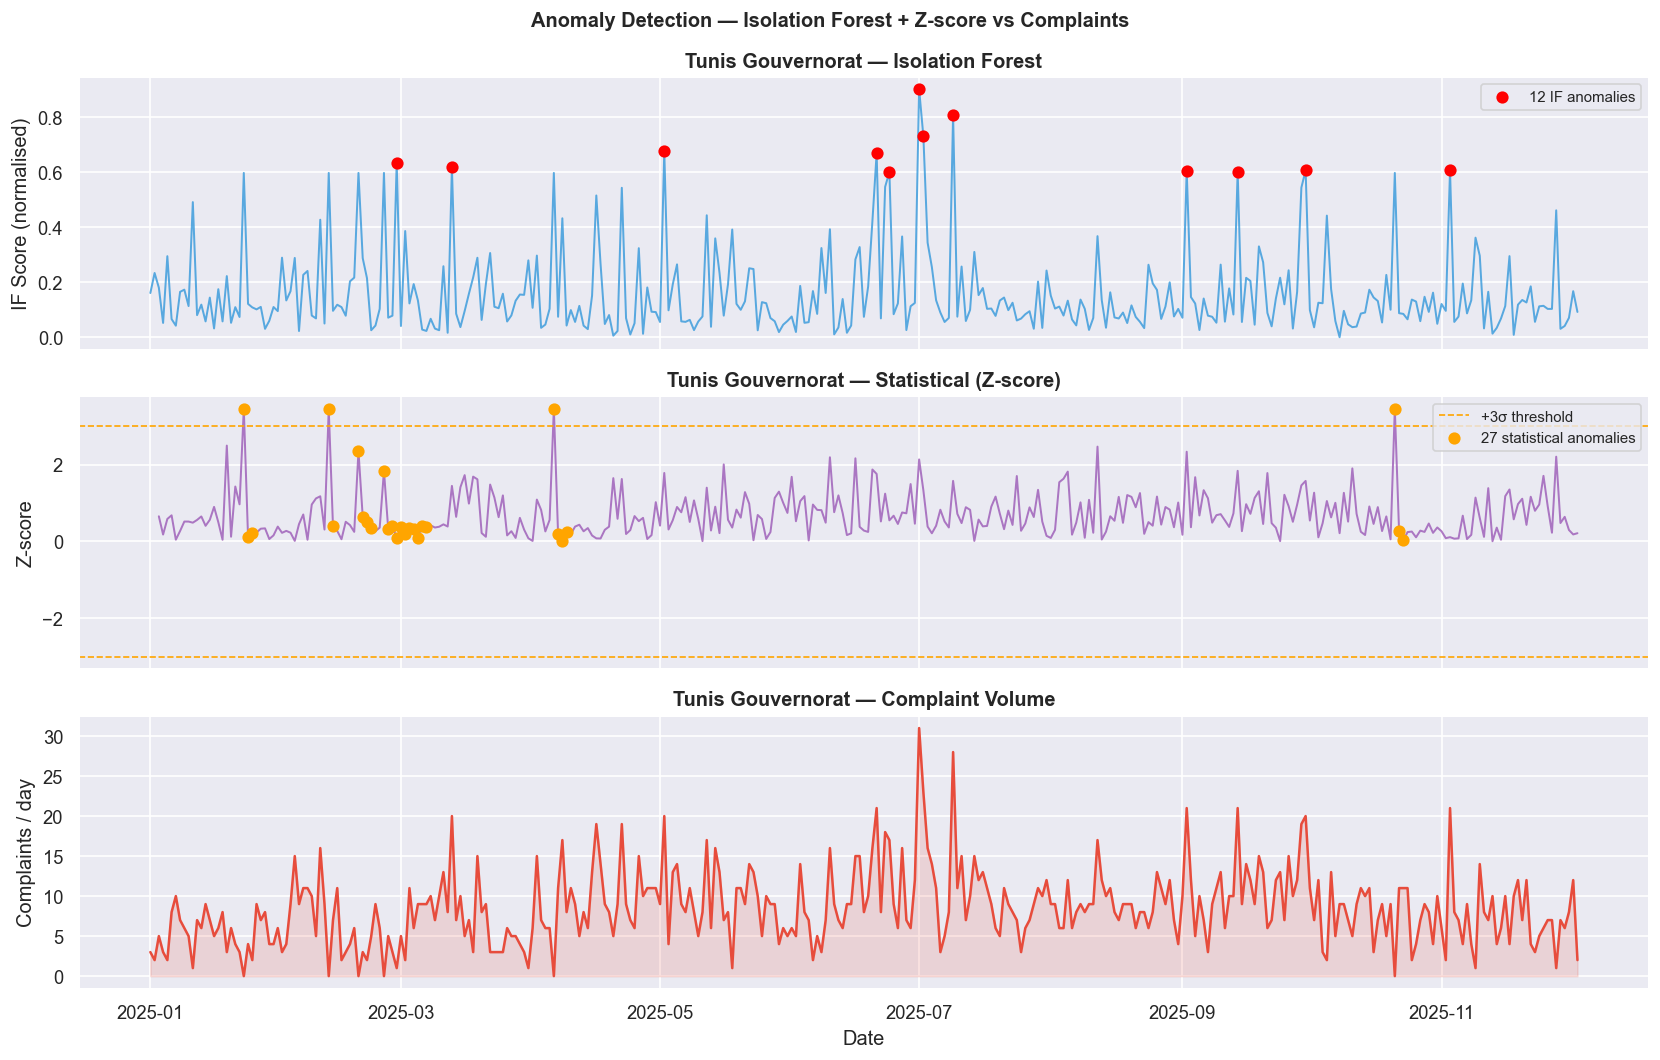

IF anomalies     : 12
Statistical anom : 27


In [52]:
top_region = complaint_agg.groupby("region")["total_complaints"].sum().idxmax()

reg_if = (
    if_df[if_df["region"] == top_region]
    .merge(
        complaint_agg[complaint_agg["region"] == top_region][["date", "total_complaints"]],
        on="date", how="left",
    )
    .sort_values("date")
)
reg_if["date"] = pd.to_datetime(reg_if["date"])

reg_st = st_df[st_df["region"] == top_region].sort_values("date").copy()
reg_st["date"] = pd.to_datetime(reg_st["date"])

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Isolation Forest score
axes[0].plot(reg_if["date"], reg_if["if_score_norm"],
             linewidth=1.2, color="#3498db", alpha=0.8)
anomalies_if = reg_if[reg_if["if_anomaly"] == 1]
axes[0].scatter(anomalies_if["date"], anomalies_if["if_score_norm"],
                color="red", s=40, zorder=5,
                label=f"{len(anomalies_if)} IF anomalies")
axes[0].set_ylabel("IF Score (normalised)")
axes[0].set_title(f"{top_region} — Isolation Forest", fontweight="bold")
axes[0].legend(fontsize=9)

# Statistical Z-score
axes[1].plot(reg_st["date"], reg_st["zscore"],
             linewidth=1.2, color="#9b59b6", alpha=0.8)
axes[1].axhline(3,  color="orange", linestyle="--", lw=1, label="+3σ threshold")
axes[1].axhline(-3, color="orange", linestyle="--", lw=1)
stat_anom = reg_st[reg_st["stat_anomaly"] == 1]
axes[1].scatter(stat_anom["date"], stat_anom["zscore"],
                color="orange", s=40, zorder=5,
                label=f"{len(stat_anom)} statistical anomalies")
axes[1].set_ylabel("Z-score")
axes[1].set_title(f"{top_region} — Statistical (Z-score)", fontweight="bold")
axes[1].legend(fontsize=9)

# Complaint volume
if "total_complaints" in reg_if.columns:
    axes[2].plot(reg_if["date"], reg_if["total_complaints"],
                 linewidth=1.5, color="#e74c3c")
    axes[2].fill_between(reg_if["date"], reg_if["total_complaints"],
                         alpha=0.15, color="#e74c3c")
    axes[2].set_ylabel("Complaints / day")
    axes[2].set_title(f"{top_region} — Complaint Volume", fontweight="bold")

axes[2].set_xlabel("Date")
plt.suptitle("Anomaly Detection — Isolation Forest + Z-score vs Complaints",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES}/ml_anomaly_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"IF anomalies     : {len(anomalies_if)}")
print(f"Statistical anom : {len(stat_anom)}")

### 2c — Anomaly heatmap by region × month

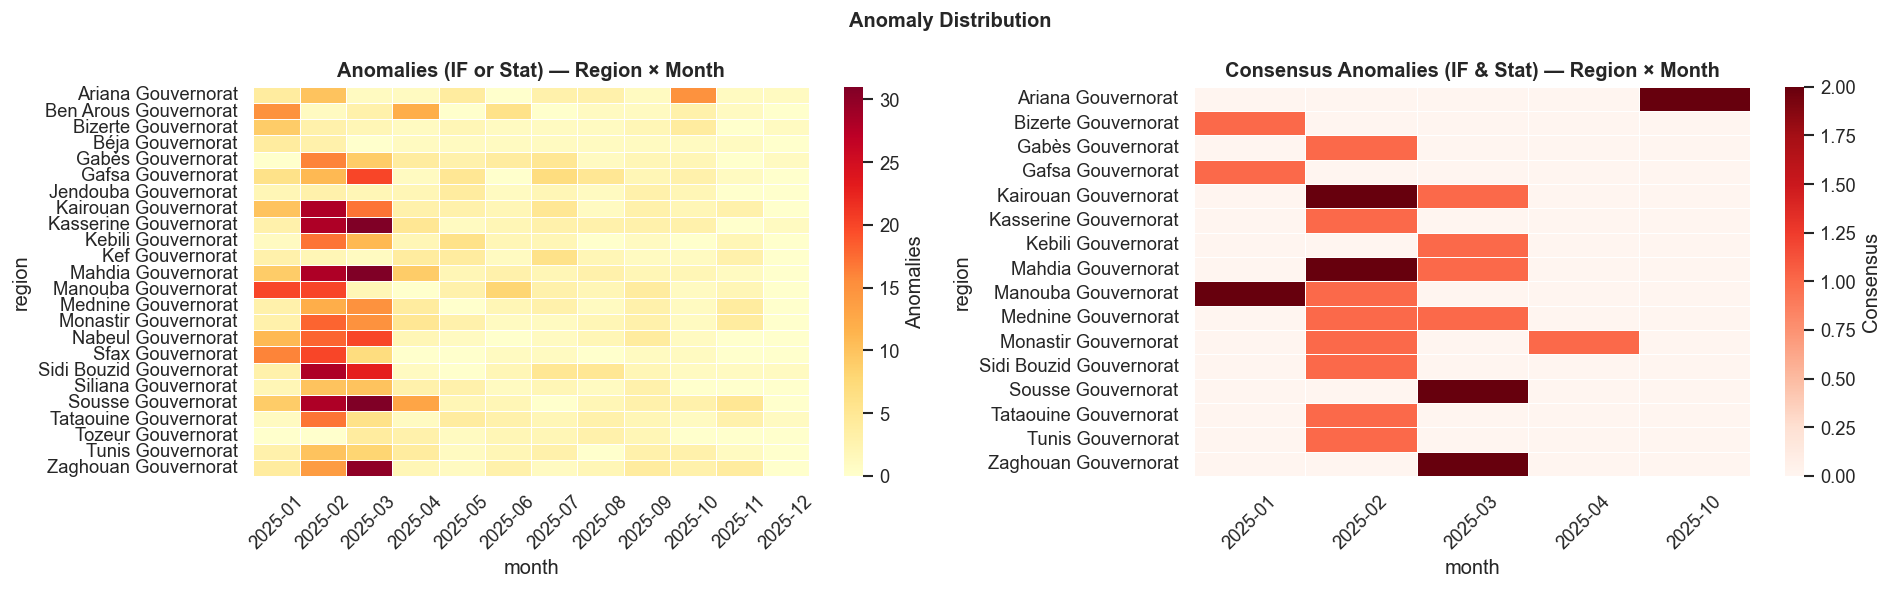

Union anomalies     : 1231
Consensus anomalies : 27


In [53]:
cb_df["date"]  = pd.to_datetime(cb_df["date"])
cb_df["month"] = cb_df["date"].dt.to_period("M").astype(str)

pivot_union = (
    cb_df[cb_df["anomaly_flag"] == 1]
    .groupby(["region", "month"]).size()
    .unstack(fill_value=0)
)

if not pivot_union.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.heatmap(pivot_union, cmap="YlOrRd", linewidths=0.3, ax=axes[0],
                cbar_kws={"label": "Anomalies"})
    axes[0].set_title("Anomalies (IF or Stat) — Region × Month", fontweight="bold")
    axes[0].tick_params(axis="x", rotation=45)

    pivot_cons = (
        cb_df[cb_df["anomaly_consensus"] == 1]
        .groupby(["region", "month"]).size()
        .unstack(fill_value=0)
    )
    if not pivot_cons.empty:
        sns.heatmap(pivot_cons, cmap="Reds", linewidths=0.3, ax=axes[1],
                    cbar_kws={"label": "Consensus"})
        axes[1].set_title("Consensus Anomalies (IF & Stat) — Region × Month",
                          fontweight="bold")
        axes[1].tick_params(axis="x", rotation=45)
    else:
        axes[1].text(0.5, 0.5, "No consensus anomalies\n(0 days IF+Stat simultaneously)",
                     ha="center", va="center", transform=axes[1].transAxes)
        axes[1].axis("off")

    plt.suptitle("Anomaly Distribution", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/ml_anomaly_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Union anomalies     : {cb_df['anomaly_flag'].sum()}")
    print(f"Consensus anomalies : {cb_df['anomaly_consensus'].sum()}")
else:
    print("No anomalies detected — heatmap skipped.")

## Cell 3 — Spike Prediction

In [ ]:
from src.models.spike_predictor import SpikePredictor

predictor  = SpikePredictor()
sp_results = predictor.run(complaint_agg, feature_matrix)

2026-05-06 13:19:57.660 | INFO     | src.models.spike_predictor:run:119 - =======================================================
2026-05-06 13:19:57.662 | INFO     | src.models.spike_predictor:run:120 - SPIKE PREDICTION
2026-05-06 13:19:57.664 | INFO     | src.models.spike_predictor:run:121 - =======================================================
2026-05-06 13:19:57.668 | INFO     | src.models.spike_predictor:run:124 - Training for 24 regions × 3 model types

2026-05-06 13:19:57.669 | INFO     | src.models.spike_predictor:run:127 -   ── Region: Ariana Gouvernorat ──────────────────────────
2026-05-06 13:19:58.165 | INFO     | src.models.spike_predictor:run:150 -     ARIMA   — MAE: 2.77  MAPE: 164.9%
13:19:58 - cmdstanpy - INFO - Chain [1] start processing
13:19:58 - cmdstanpy - INFO - Chain [1] done processing
2026-05-06 13:19:58.857 | INFO     | src.models.spike_predictor:run:165 -     Prophet — MAE: 2.44  MAPE: 143.0%
2026-05-06 13:20:00.844 | INFO     | src.models.spike_predictor:

### 3a — Performance table
FIX N2: safe access — only include model keys that actually exist per region.

In [ ]:
scores_raw = sp_results["scores"]

rows = []
for region, v in scores_raw.items():
    row = {"region": region}
    for model in ("arima", "prophet", "xgboost"):
        row[f"{model}_mae"]  = v[model]["mae"]  if model in v else float("nan")
        row[f"{model}_mape"] = v[model]["mape"] if model in v else float("nan")
    row["winner"] = min(v, key=lambda k: v[k]["mae"]) if v else "N/A"
    rows.append(row)

scores = pd.DataFrame(rows)
print("=== SPIKE PREDICTION — PERFORMANCE BY REGION ===")
display(scores.round(2))  # type: ignore[name-defined]

n_xgb = (scores["winner"] == "xgboost").sum()
print(f"\nXGBoost wins in {n_xgb}/{len(scores)} regions")
if "xgboost_mae" in scores.columns:
    valid_xgb = scores["xgboost_mae"].dropna()
    print(f"Mean XGBoost MAE  : {valid_xgb.mean():.2f}")
    best_idx = valid_xgb.idxmin()
    print(f"Best region       : {scores.loc[best_idx, 'region']} "
          f"(MAE={valid_xgb.min():.2f})")

=== SPIKE PREDICTION — PERFORMANCE BY REGION ===


,region,arima_mae,arima_mape,prophet_mae,prophet_mape,xgboost_mae,xgboost_mape,winner
0,Ariana Gouvernorat,2.77,164.95,2.44,142.99,1.78,133.86,xgboost
1,Ben Arous Gouvernorat,2.74,68.87,5.29,100.00,2.34,54.28,xgboost
2,Bizerte Gouvernorat,7.26,69.35,8.32,90.98,5.45,35.45,xgboost
3,Béja Gouvernorat,0.93,34.72,0.99,46.57,0.08,9.49,xgboost
4,Gabès Gouvernorat,1.33,46.90,1.71,36.74,0.12,38.74,xgboost
5,Gafsa Gouvernorat,1.80,38.36,4.20,133.40,1.98,46.84,arima
6,Jendouba Gouvernorat,1.16,36.47,1.32,48.21,0.51,28.61,xgboost
7,Kairouan Gouvernorat,1.34,95.78,1.95,64.25,1.11,81.78,xgboost
8,Kasserine Gouvernorat,0.58,32.76,1.13,65.07,0.36,23.15,xgboost
9,Kebili Gouvernorat,0.72,23.65,0.13,72.11,0.06,44.93,xgboost



XGBoost wins in 20/24 regions
Mean XGBoost MAE  : 1.04
Best region       : Tozeur Gouvernorat (MAE=0.03)


### 3b — MAE comparison bar chart

C:\Users\c50057188\AppData\Local\Temp\ipykernel_14180\744607956.py:30: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\c50057188\AppData\Local\Temp\ipykernel_14180\744607956.py:31: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(f"{FIGURES}/ml_spike_model_comparison.png", dpi=150, bbox_inches="tight")
c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


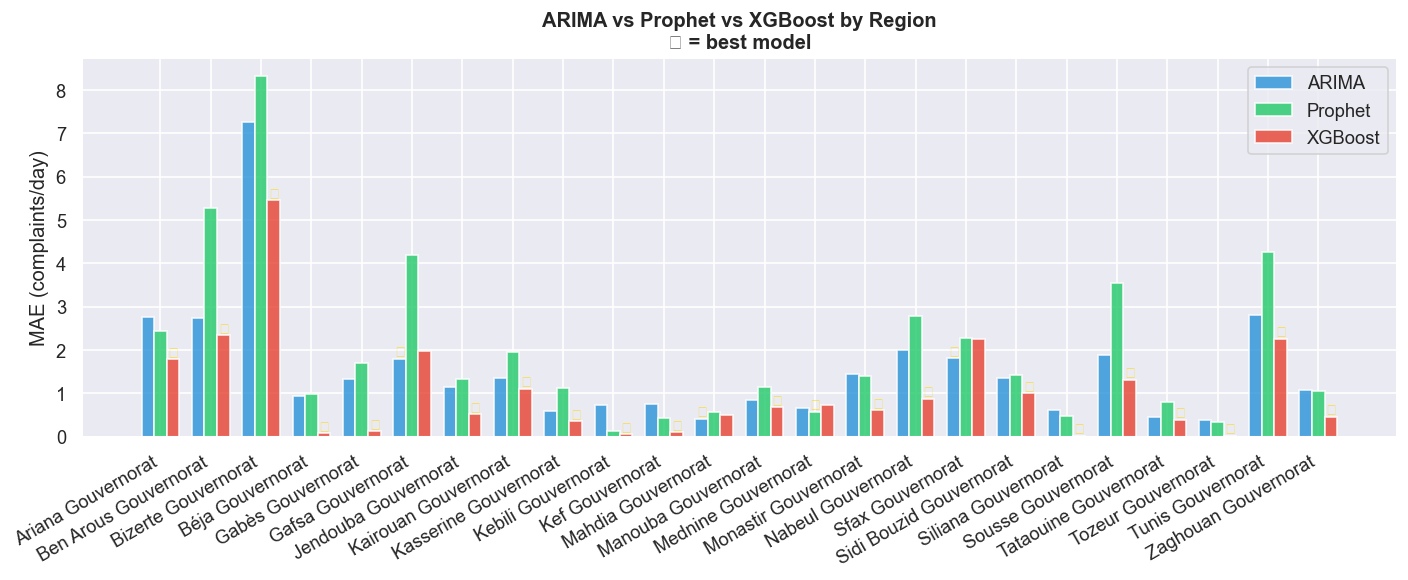

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(scores))
w = 0.25

for offset, col, label, color in [
    (-w, "arima_mae",   "ARIMA",   "#3498db"),
    ( 0, "prophet_mae", "Prophet", "#2ecc71"),
    ( w, "xgboost_mae", "XGBoost", "#e74c3c"),
]:
    vals = scores[col].fillna(0)
    ax.bar(x + offset, vals, w, label=label, color=color, alpha=0.85)

# Star on winner
for j, (_, row) in enumerate(scores.iterrows()):
    winner = row.get("winner", "")
    col_map = {"arima": ("arima_mae", -w), "prophet": ("prophet_mae", 0),
               "xgboost": ("xgboost_mae", w)}
    if winner in col_map:
        ycol, xoff = col_map[winner]
        val = row.get(ycol, 0)
        if not pd.isna(val):
            ax.text(j + xoff, val + 0.05, "★", ha="center", fontsize=9, color="gold")

ax.set_xticks(x)
ax.set_xticklabels(scores["region"], rotation=30, ha="right")
ax.set_ylabel("MAE (complaints/day)")
ax.set_title("ARIMA vs Prophet vs XGBoost by Region\n★ = best model",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/ml_spike_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 3c — Forecast vs actual for best region
FIX N3: sp_results["forecasts"] is a DataFrame (not a dict of dicts).
The forecast DataFrame has columns: date, forecast, model_used, region.
Actual values must be joined from complaint_agg.

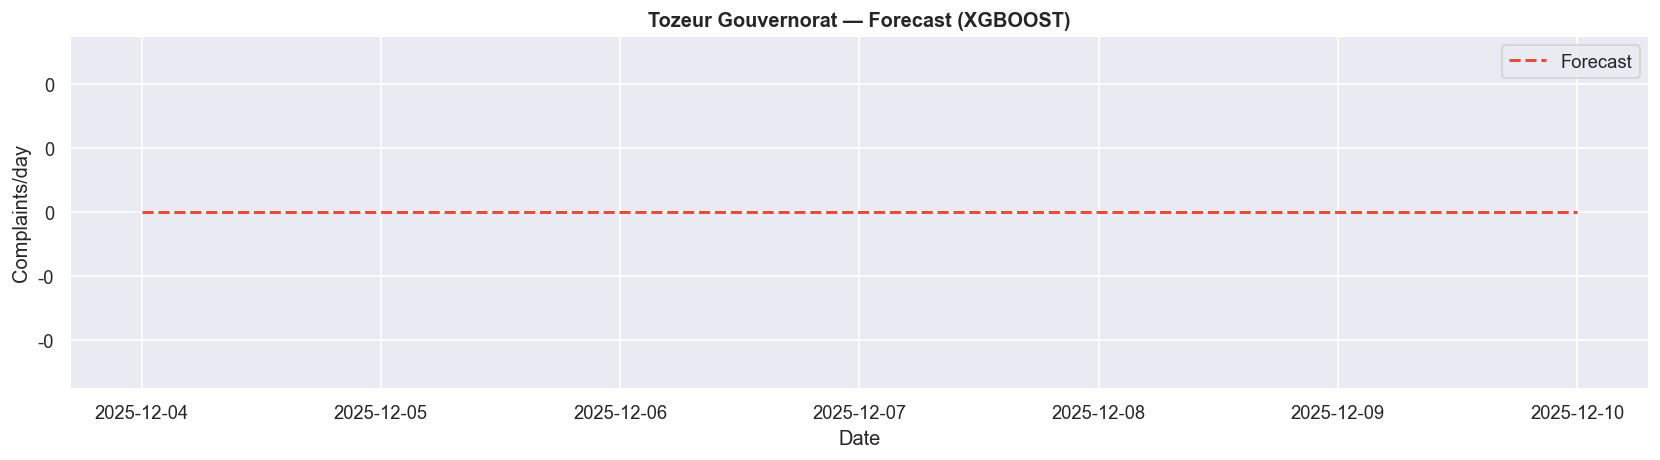

In [ ]:
forecasts_df = sp_results["forecasts"]

if forecasts_df.empty:
    print("No forecasts available.")
else:
    # Pick best region by lowest XGBoost MAE (or first available)
    if "xgboost_mae" in scores.columns:
        valid = scores.dropna(subset=["xgboost_mae"])
        best_region = valid.loc[valid["xgboost_mae"].idxmin(), "region"]
    else:
        best_region = scores["region"].iloc[0]

    fc = forecasts_df[forecasts_df["region"] == best_region].copy()
    fc["date"] = pd.to_datetime(fc["date"])

    # Join actual complaints for the same period
    actual_sub = complaint_agg[
        (complaint_agg["region"] == best_region) &
        (pd.to_datetime(complaint_agg["date"]).isin(fc["date"]))
    ][["date", "total_complaints"]].copy()
    actual_sub["date"] = pd.to_datetime(actual_sub["date"])
    fc = fc.merge(actual_sub, on="date", how="left")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(fc["date"], fc["forecast"],
            linewidth=1.8, color="#e74c3c", linestyle="--", label="Forecast")
    if "total_complaints" in fc.columns and fc["total_complaints"].notna().any():
        ax.plot(fc["date"], fc["total_complaints"],
                linewidth=2, color="#64ffda", label="Actual")

    model_used = fc["model_used"].iloc[0] if "model_used" in fc.columns else "?"
    ax.set_title(f"{best_region} — Forecast ({model_used.upper()})", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Complaints/day")
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/ml_spike_forecast.png", dpi=150, bbox_inches="tight")
    plt.show()

## Cell 4 — Root Cause Classification

In [ ]:
from src.models.root_cause_classifier import RootCauseClassifier

classifier = RootCauseClassifier()
rc_results = classifier.run(complaints_clean, feature_matrix)

2026-05-06 01:39:37.632 | INFO     | src.models.root_cause_classifier:run:164 - =======================================================
2026-05-06 01:39:37.643 | INFO     | src.models.root_cause_classifier:run:165 - ROOT CAUSE CLASSIFICATION
2026-05-06 01:39:37.647 | INFO     | src.models.root_cause_classifier:run:166 - =======================================================
2026-05-06 01:39:37.662 | INFO     | src.models.root_cause_classifier:run:170 - 
[1/4] Building labelled dataset ...
2026-05-06 01:39:37.729 | INFO     | src.models.root_cause_classifier:_build_dataset:261 -   Using subcategory column: complaint_subcategory
2026-05-06 01:39:37.737 | INFO     | src.models.root_cause_classifier:_build_dataset:262 -   Sample values: {'Débit Faible Internet Mobile': 7050, 'Echec Émission/Réception Appel': 6408, "Pas D'Accès Internet Mobile": 3369, 'Echec Connexion Internet Mobile': 2909, 'Pas De Couverture Voix': 2186}
2026-05-06 01:39:37.896 | INFO     | src.models.root_cause_classifi

### 4a — Performance summary

In [ ]:
best    = rc_results["best_model"]
rf_r    = rc_results["rf_report"]
xg_r    = rc_results["xgb_report"]
classes = rc_results.get("classes", [])

print("=== ROOT CAUSE CLASSIFICATION ===")
print(f"  Best model : {best}")
for model_name, report in [("Random Forest", rf_r), ("XGBoost", xg_r)]:
    if report:
        acc = report.get("accuracy", 0)
        f1  = report.get("f1_macro", 0)
        cv_mean = report.get("cv_f1_mean", 0)
        cv_std  = report.get("cv_f1_std", 0)
        print(f"  {model_name:<15} Acc={acc:.3f}  F1-macro={f1:.3f}  "
              f"CV-F1={cv_mean:.3f}±{cv_std:.3f}")

=== ROOT CAUSE CLASSIFICATION ===
  Best model : xgboost
  Random Forest   Acc=0.485  F1-macro=0.352  CV-F1=0.340±0.017
  XGBoost         Acc=0.465  F1-macro=0.370  CV-F1=0.311±0.008


### 4b — Confusion matrices

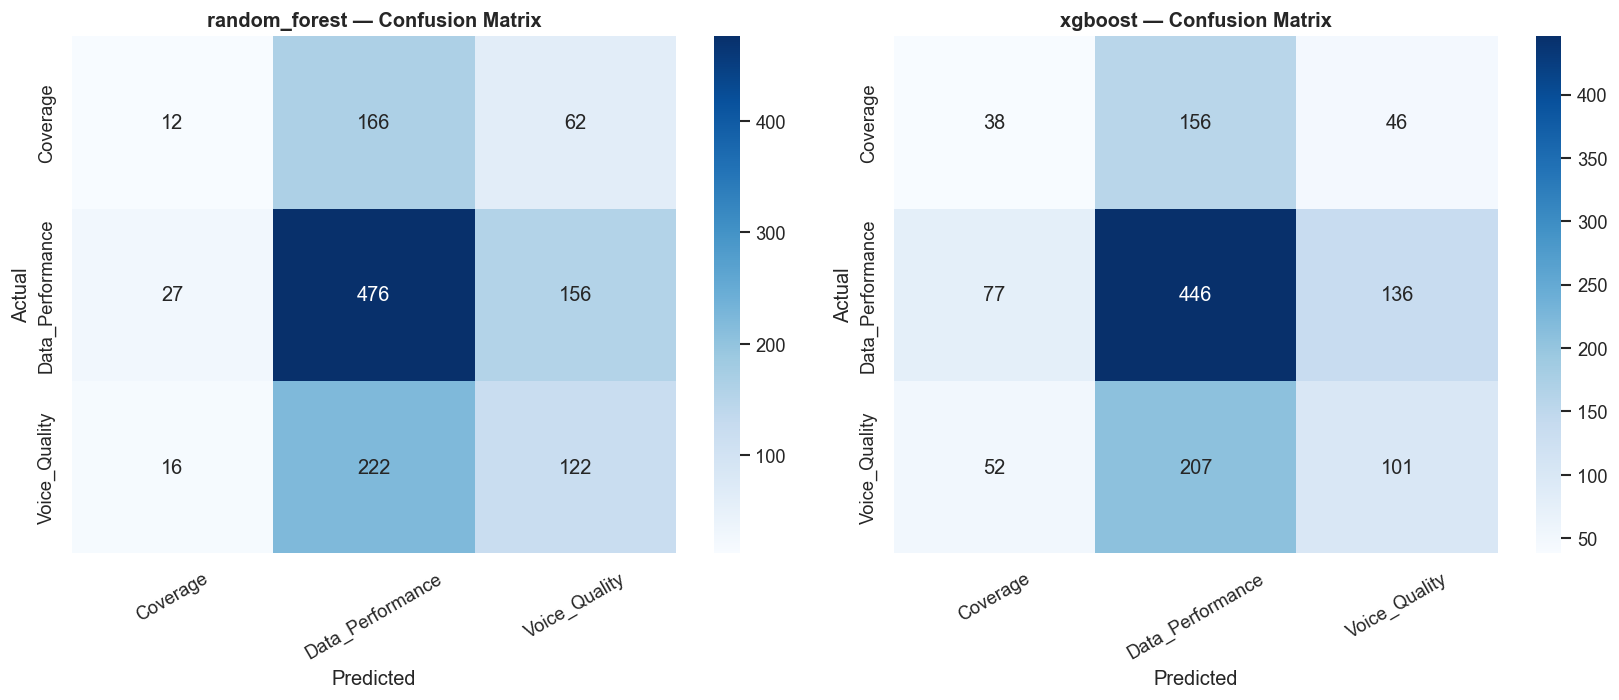

In [ ]:
cms = rc_results.get("confusion_matrices", {})
if cms and classes:
    fig, axes = plt.subplots(1, len(cms), figsize=(7 * len(cms), 6))
    if len(cms) == 1:
        axes = [axes]
    for ax, (name, cm) in zip(axes, cms.items()):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=classes, yticklabels=classes, ax=ax)
        ax.set_title(f"{name} — Confusion Matrix", fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/ml_rootcause_confusion.png", dpi=150, bbox_inches="tight")
    plt.show()

### 4c — Feature importance

Available columns: ['feature', 'importance_rf', 'importance_xgb', 'importance_mean']
Feature col: 'feature'  |  Importance col: 'importance_rf'


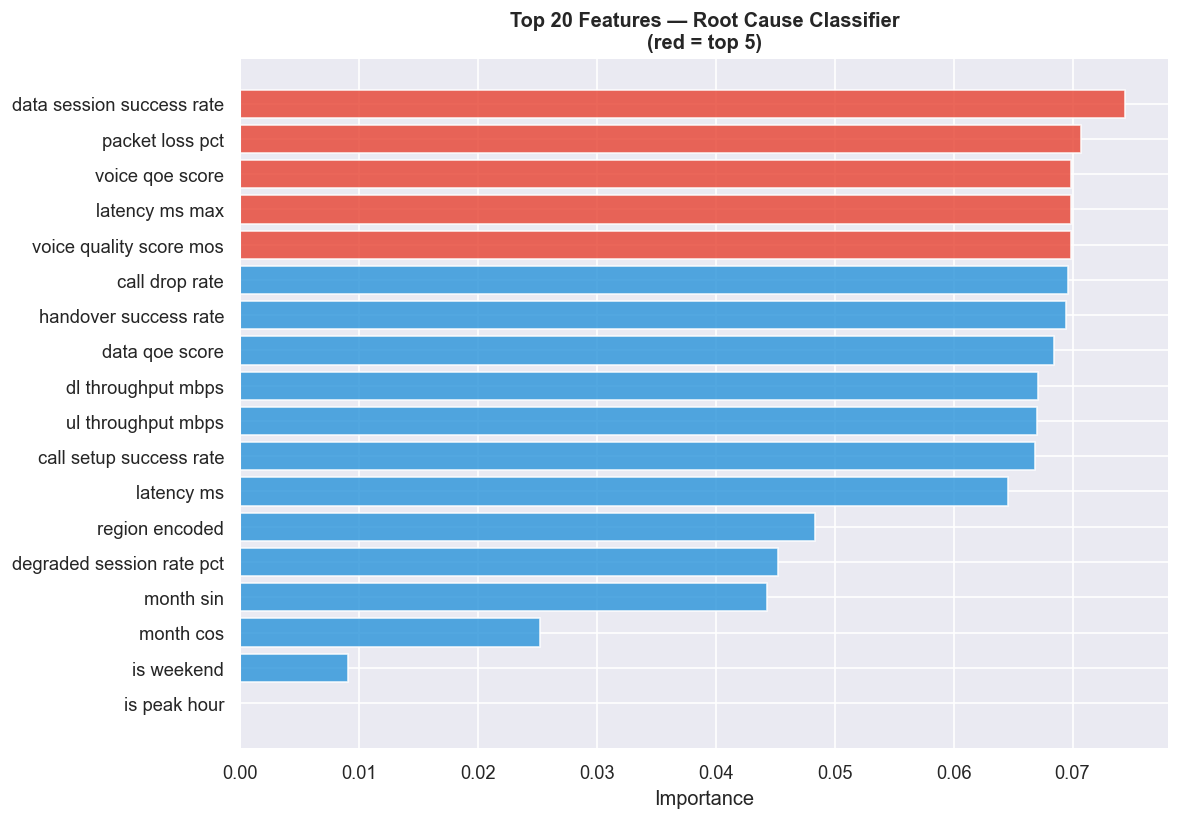


Top 5 features:
  data_session_success_rate_mean                0.0744
  packet_loss_pct_mean                          0.0708
  voice_qoe_score_mean                          0.0699
  latency_ms_max                                0.0699
  voice_quality_score_mos_mean                  0.0699


In [ ]:
fi = rc_results.get("feature_importance")
if fi is not None and not fi.empty:
    print("Available columns:", list(fi.columns))
    feat_col = next((c for c in fi.columns if "feature" in c.lower()), fi.columns[0])
    imp_col  = next(
        (c for c in fi.columns if c in ("importance_mean", "importance_rf",
                                         "importance_xgb", "importance")),
        fi.select_dtypes(include="number").columns[0],
    )
    print(f"Feature col: '{feat_col}'  |  Importance col: '{imp_col}'")

    top20 = fi.sort_values(imp_col, ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(
        top20[feat_col].str.replace("_mean", "").str.replace("_", " "),
        top20[imp_col],
        color=["#e74c3c" if i < 5 else "#3498db" for i in range(len(top20))],
        alpha=0.85,
    )
    ax.set_title("Top 20 Features — Root Cause Classifier\n(red = top 5)", fontweight="bold")
    ax.set_xlabel("Importance")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/ml_rootcause_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nTop 5 features:")
    for _, row in top20.head(5).iterrows():
        print(f"  {row[feat_col]:<45} {row[imp_col]:.4f}")
else:
    print("Feature importance not available.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# ADD THIS CELL in Notebook 05 immediately after:
#   rc_results = classifier.run(complaints_clean, feature_matrix)
#
# Then RUN IT — it writes root_cause_results.json so the dashboard
# shows Per-Class F1, Confusion Matrix, and Classification Report.
# ─────────────────────────────────────────────────────────────────────

import json
import numpy as np
import pandas as pd
from pathlib import Path


class _NpEncoder(json.JSONEncoder):
    """Custom encoder — handles all numpy/pandas types that json.dump chokes on."""
    def default(self, obj):
        if isinstance(obj, np.integer):   return int(obj)
        if isinstance(obj, np.floating):  return float(obj)
        if isinstance(obj, np.bool_):     return bool(obj)
        if isinstance(obj, np.ndarray):   return obj.tolist()
        if isinstance(obj, pd.DataFrame): return obj.fillna(0).to_dict(orient='records')
        if isinstance(obj, pd.Series):    return obj.fillna(0).tolist()
        return super().default(obj)


# ── Build the dict to save ────────────────────────────────────────────
# We exclude shap_values (too large), X_test, y_test (not needed by UI)
save_dict = {
    'best_model':  rc_results.get('best_model'),
    'classes':     rc_results.get('classes', []),

    # Evaluation reports — contain accuracy, f1_macro, cv scores,
    # classification_report (per-class precision/recall/F1), confusion_matrix
    'rf_report':   rc_results.get('rf_report',  {}),
    'xgb_report':  rc_results.get('xgb_report', {}),

    # Feature importance DataFrame → list of dicts
    'feature_importance': rc_results.get('feature_importance', []),

    # confusion_matrices = { 'random_forest': 2D np.array,
    #                         'xgboost':       2D np.array }
    'confusion_matrices':  rc_results.get('confusion_matrices', {}),
}

# ── Sanity check before saving ────────────────────────────────────────
xgb_r = save_dict.get('xgb_report', {})
cr    = xgb_r.get('classification_report', {})
cms   = save_dict.get('confusion_matrices', {})

print('=== Pre-save sanity check ===')
print(f'  best_model            : {save_dict["best_model"]}')
print(f'  classes               : {save_dict["classes"]}')
print(f'  xgb accuracy          : {xgb_r.get("accuracy")}')
print(f'  xgb f1_macro          : {xgb_r.get("f1_macro")}')
print(f'  classification_report : {len(cr)} keys  ({list(cr.keys())[:4]}...)')
print(f'  confusion_matrices    : {list(cms.keys())}')
fi = save_dict.get('feature_importance')
if hasattr(fi, '__len__'):
    n_fi = len(fi) if isinstance(fi, list) else len(fi)
    print(f'  feature_importance    : {n_fi} features')

# ── Write JSON ────────────────────────────────────────────────────────
out_path = Path('models/classification/root_cause_results.json')
out_path.parent.mkdir(parents=True, exist_ok=True)

with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(save_dict, f, cls=_NpEncoder, indent=2, ensure_ascii=False)

size_kb = out_path.stat().st_size / 1024
print(f'\n✓  Saved  {out_path}  ({size_kb:.1f} KB)')

# ── Verify the file is valid JSON ─────────────────────────────────────
with open(out_path, encoding='utf-8') as f:
    check = json.load(f)

xgb_check = check.get('xgb_report', {})
cr_check   = xgb_check.get('classification_report', {})
cms_check  = check.get('confusion_matrices', {})

print('\n=== Post-save verification ===')
print(f'  xgb accuracy (from file)   : {xgb_check.get("accuracy")}')
print(f'  classification_report keys : {list(cr_check.keys())[:5]}')
xgb_cm = cms_check.get('xgboost', [])
print(f'  confusion_matrix shape     : {len(xgb_cm)}×{len(xgb_cm[0]) if xgb_cm else 0}')
print('\n→ Dashboard will now show:')
print('   ✓ Per-Class F1 Scores chart')
print('   ✓ Confusion Matrix heatmap')
print('   ✓ Classification Report table')
print('   ✓ Accuracy / F1 KPI cards')
print('\n→ Restart FastAPI (or hit /api/analytics/status?refresh=true) to clear the cache.')

=== Pre-save sanity check ===
  best_model            : xgboost
  classes               : ['Coverage', 'Data_Performance', 'Voice_Quality']
  xgb accuracy          : 0.46465448768864176
  xgb f1_macro          : 0.36950467503351
  classification_report : 6 keys  (['Coverage', 'Data_Performance', 'Voice_Quality', 'accuracy']...)
  confusion_matrices    : ['random_forest', 'xgboost']
  feature_importance    : 18 features

✓  Saved  models\classification\root_cause_results.json  (31.3 KB)

=== Post-save verification ===
  xgb accuracy (from file)   : 0.46465448768864176
  classification_report keys : ['Coverage', 'Data_Performance', 'Voice_Quality', 'accuracy', 'macro avg']
  confusion_matrix shape     : 3×3

→ Dashboard will now show:
   ✓ Per-Class F1 Scores chart
   ✓ Confusion Matrix heatmap
   ✓ Classification Report table
   ✓ Accuracy / F1 KPI cards

→ Restart FastAPI (or hit /api/analytics/status?refresh=true) to clear the cache.


### 4d — SHAP explainability
FIX N9: handles both list (one array per class) and 3D ndarray shap_values.

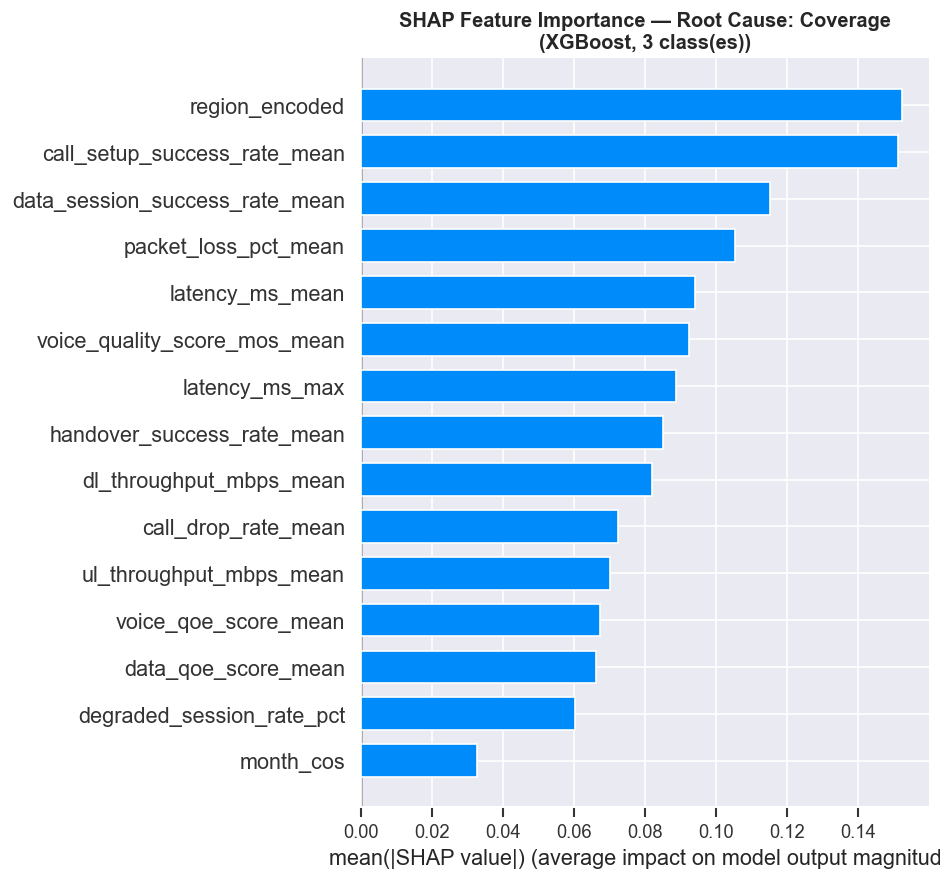

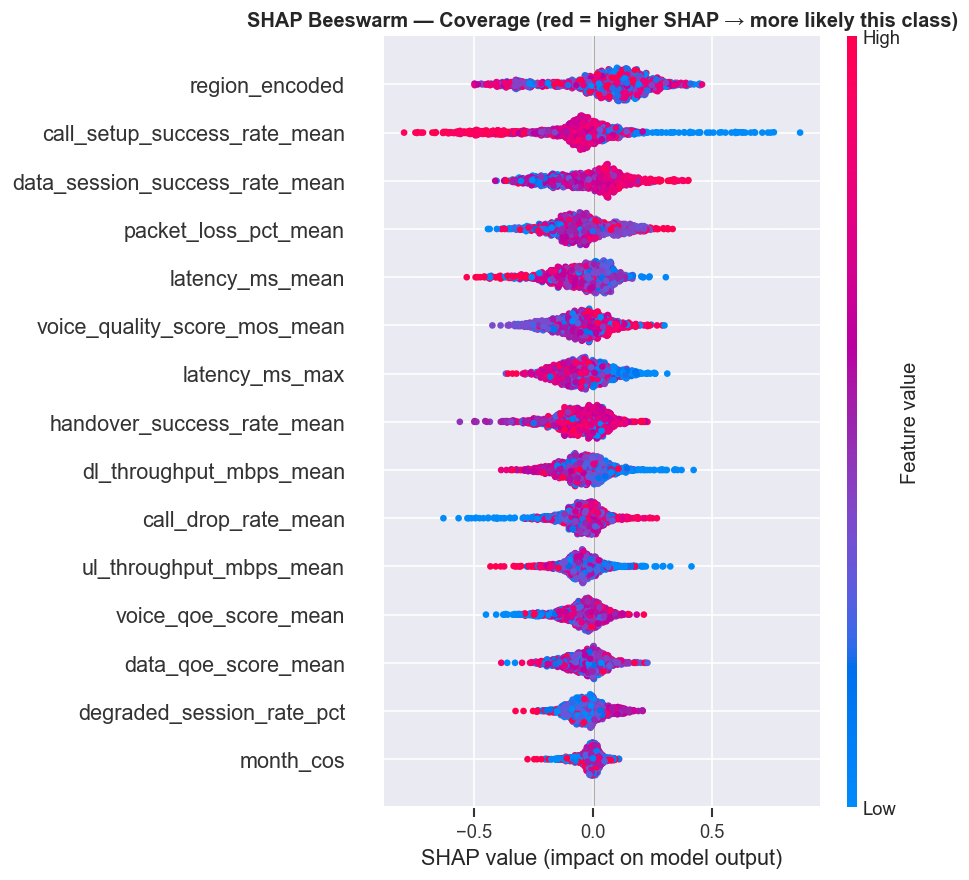

SHAP values computed ✓ — explainability available for thesis jury


In [ ]:
shap_values = rc_results.get("shap_values")
X_test_rc   = rc_results.get("X_test")

if shap_values is None:
    print("SHAP values not available — install with: pip install shap")
    print("Re-run after installing to generate explainability plots.")
elif X_test_rc is None:
    print("X_test not available for SHAP plot.")
else:
    try:
        import shap

        # FIX N9: handle both list and ndarray shap_values formats
        if isinstance(shap_values, list):
            # shap_values is a list of arrays — one per class
            # Use the class with most variance (first class as default)
            sv_2d = shap_values[0] if len(shap_values) > 0 else None
            n_classes = len(shap_values)
            logger._info = lambda *a, **k: None   # silence shap internal logs
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            # shape: (n_samples, n_features, n_classes) — take class index 0
            sv_2d     = shap_values[:, :, 0]
            n_classes = shap_values.shape[2]
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
            sv_2d     = shap_values
            n_classes = 1
        else:
            sv_2d     = None
            n_classes = 0

        target_class = classes[0] if classes else "Class 0"

        if sv_2d is not None:
            fig, ax = plt.subplots(figsize=(10, 6))
            shap.summary_plot(
                sv_2d, X_test_rc,
                max_display=15, show=False,
                plot_type="bar",
            )
            plt.title(
                f"SHAP Feature Importance — Root Cause: {target_class}\n"
                f"(XGBoost, {n_classes} class(es))",
                fontweight="bold",
            )
            plt.tight_layout()
            plt.savefig(f"{FIGURES}/ml_shap_bar.png", dpi=150, bbox_inches="tight")
            plt.show()

            # Beeswarm plot for richer interpretation
            plt.figure(figsize=(10, 6))
            shap.summary_plot(sv_2d, X_test_rc, max_display=15, show=False)
            plt.title(
                f"SHAP Beeswarm — {target_class} (red = higher SHAP → more likely this class)",
                fontweight="bold",
            )
            plt.tight_layout()
            plt.savefig(f"{FIGURES}/ml_shap_summary.png", dpi=150, bbox_inches="tight")
            plt.show()
            print("SHAP values computed ✓ — explainability available for thesis jury")
        else:
            print("Could not extract 2D SHAP array — check shap_values format.")

    except Exception as exc:
        print(f"SHAP plot failed: {exc}")

## Cell 5 — Customer Clustering

In [ ]:
from src.models.customer_clustering import CustomerClusterer

clusterer  = CustomerClusterer()
cl_results = clusterer.run(kpi_clean, complaints_clean)

2026-05-06 01:40:52.512 | INFO     | src.models.customer_clustering:run:158 - =======================================================
2026-05-06 01:40:52.518 | INFO     | src.models.customer_clustering:run:159 - CUSTOMER CLUSTERING
2026-05-06 01:40:52.522 | INFO     | src.models.customer_clustering:run:160 - =======================================================
2026-05-06 01:40:52.523 | INFO     | src.models.customer_clustering:run:162 - 
[1/5] Building per-user feature matrix ...
2026-05-06 01:40:59.648 | INFO     | src.models.customer_clustering:_build_user_features:258 -   User feature matrix: 20,299 users × 37 cols
2026-05-06 01:40:59.690 | INFO     | src.models.customer_clustering:run:167 -   Sampled 8,000 from 20,299 users
2026-05-06 01:40:59.693 | INFO     | src.models.customer_clustering:run:171 - 
[2/5] Scaling and applying PCA ...
2026-05-06 01:40:59.759 | INFO     | src.models.customer_clustering:_scale_and_reduce:280 -   PCA variance explained (2 components): 37.7%
2026-0

### 5a — Clustering metrics

In [ ]:
km        = cl_results.get("kmeans_results", {})
db        = cl_results.get("dbscan_results", {})
optimal_k = cl_results.get("optimal_k", "?")

# FIX N5: use pca_variance_pct from results dict — not hardcoded
pca_var   = cl_results.get("pca_variance_pct", 0.0)

print("=== CUSTOMER CLUSTERING ===")
print(f"  Optimal K        : {optimal_k}")
print(f"  Silhouette score : {km.get('silhouette_score', 0):.3f}")
print(f"  Davies-Bouldin   : {km.get('davies_bouldin', 0):.3f}")
print(f"  DBSCAN clusters  : {db.get('n_clusters','?')} + {db.get('n_noise', 0)} noise")
print(f"  PCA variance     : {pca_var:.1f}%")
print()
sil = km.get("silhouette_score", 0)
dbi = km.get("davies_bouldin", 0)
print(f"  Interpretation:")
print(f"    Silhouette={sil:.3f} — {'VALID (> 0.25)' if sil > 0.25 else 'WEAK (≤ 0.25)'} clustering structure")
print(f"    Davies-Bouldin={dbi:.3f} — {'acceptable (< 2.0)' if dbi < 2.0 else 'poor (≥ 2.0)'} separation")

=== CUSTOMER CLUSTERING ===
  Optimal K        : 2
  Silhouette score : 0.209
  Davies-Bouldin   : 1.887
  DBSCAN clusters  : 1 + 218 noise
  PCA variance     : 37.7%

  Interpretation:
    Silhouette=0.209 — WEAK (≤ 0.25) clustering structure
    Davies-Bouldin=1.887 — acceptable (< 2.0) separation


### 5b — Elbow + Silhouette curves
FIX N4: uses cl_results directly — no undefined variable `s`.

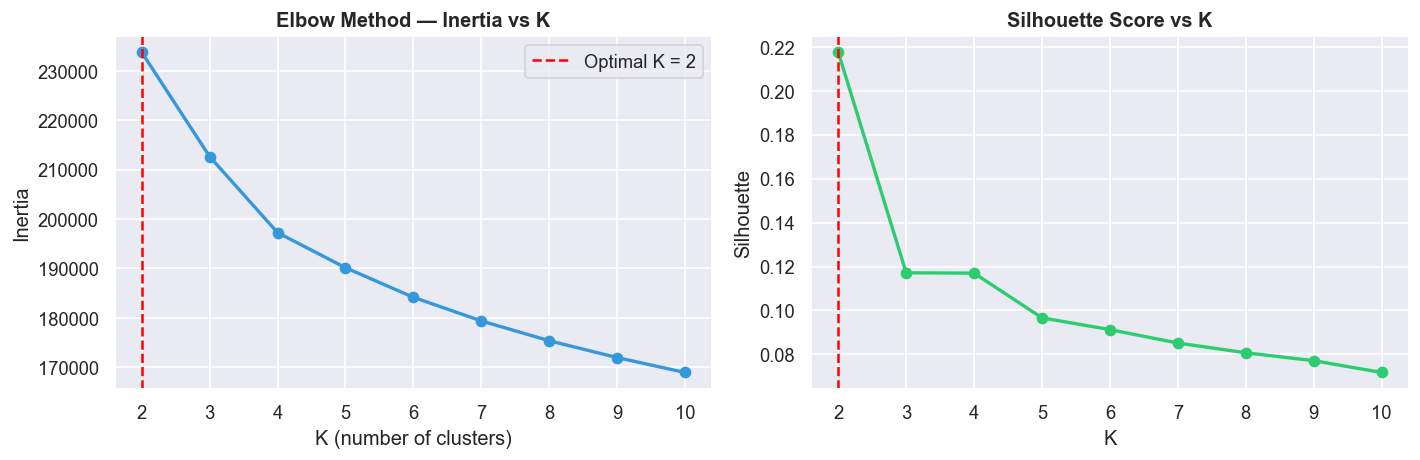

In [ ]:
elbow_data = cl_results.get("elbow_data", {})
sil_data   = cl_results.get("silhouette_data", {})

if elbow_data.get("k") and sil_data.get("k"):
    ks      = elbow_data["k"]
    inertia = elbow_data["inertia"]
    sil_k   = sil_data["k"]
    sil_s   = sil_data["score"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ks, inertia, marker="o", color="#3498db", linewidth=2)
    axes[0].set_title("Elbow Method — Inertia vs K", fontweight="bold")
    axes[0].set_xlabel("K (number of clusters)")
    axes[0].set_ylabel("Inertia")
    if optimal_k in ks:
        axes[0].axvline(optimal_k, color="red", linestyle="--", lw=1.5,
                        label=f"Optimal K = {optimal_k}")
        axes[0].legend()

    axes[1].plot(sil_k, sil_s, marker="o", color="#2ecc71", linewidth=2)
    axes[1].set_title("Silhouette Score vs K", fontweight="bold")
    axes[1].set_xlabel("K")
    axes[1].set_ylabel("Silhouette")
    if optimal_k in sil_k:
        axes[1].axvline(optimal_k, color="red", linestyle="--", lw=1.5)

    plt.tight_layout()
    plt.savefig(f"{FIGURES}/ml_clustering_elbow.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Elbow/silhouette data not available.")

### 5c — PCA scatter plot
FIX N5: PCA variance label reads from cl_results.

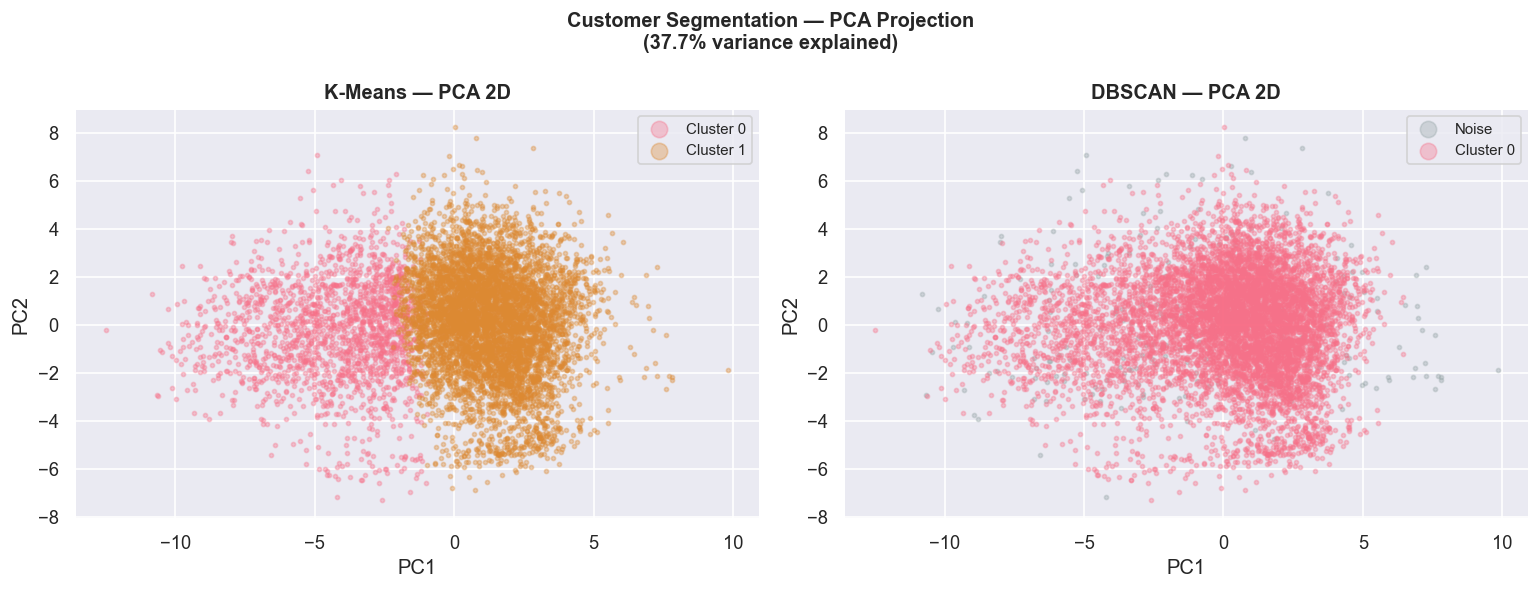

In [ ]:
pca_raw  = cl_results.get("pca_coords")
km_labels = cl_results.get("kmeans_results", {}).get("labels")
db_labels = cl_results.get("dbscan_results", {}).get("labels")

if pca_raw is not None:
    pca_df = pd.DataFrame(pca_raw, columns=["pca1", "pca2"])
    if km_labels is not None:
        pca_df["kmeans_cluster"] = np.array(km_labels)[: len(pca_df)]
    if db_labels is not None:
        pca_df["dbscan_cluster"] = np.array(db_labels)[: len(pca_df)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, col, title in [
        (axes[0], "kmeans_cluster", "K-Means"),
        (axes[1], "dbscan_cluster", "DBSCAN"),
    ]:
        if col in pca_df.columns:
            for k in sorted(pca_df[col].unique()):
                sub   = pca_df[pca_df[col] == k]
                label = f"Cluster {k}" if k >= 0 else "Noise"
                color = "#95a5a6" if k < 0 else COLORS[k % len(COLORS)]
                ax.scatter(sub["pca1"], sub["pca2"],
                           s=6, alpha=0.35, color=color, label=label)
            ax.set_title(f"{title} — PCA 2D", fontweight="bold")
            ax.set_xlabel("PC1")
            ax.set_ylabel("PC2")
            ax.legend(markerscale=4, fontsize=9)
        else:
            ax.text(0.5, 0.5, f"{col}\nnot available",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(title, fontweight="bold")

    plt.suptitle(
        f"Customer Segmentation — PCA Projection\n({pca_var:.1f}% variance explained)",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/ml_clustering_pca.png", dpi=150, bbox_inches="tight")
    plt.show()

### 5d — Cluster profiles

=== K-MEANS CLUSTER PROFILES ===


,kmeans_cluster,n_users,dl_throughput_mbps_mean,ul_throughput_mbps_mean,latency_ms_mean,packet_loss_pct_mean,data_session_success_rate_mean,data_qoe_score_mean,call_setup_success_rate_mean,call_drop_rate_mean,voice_quality_score_mos_mean,voice_qoe_score_mean,qoe_score_mean,cluster_label,pct_of_users
0,0,1875,28.212270,6.873895,74.050048,3.025824,81.341021,61.125472,83.030269,3.012695,3.133721,64.612303,64.122002,Premium — High QoE & Low Complaints,23.4
1,1,6125,33.781331,7.983948,63.098681,2.708585,88.424951,67.616064,90.506273,2.691722,3.440754,70.682895,75.796664,Standard — Moderate QoE,76.6


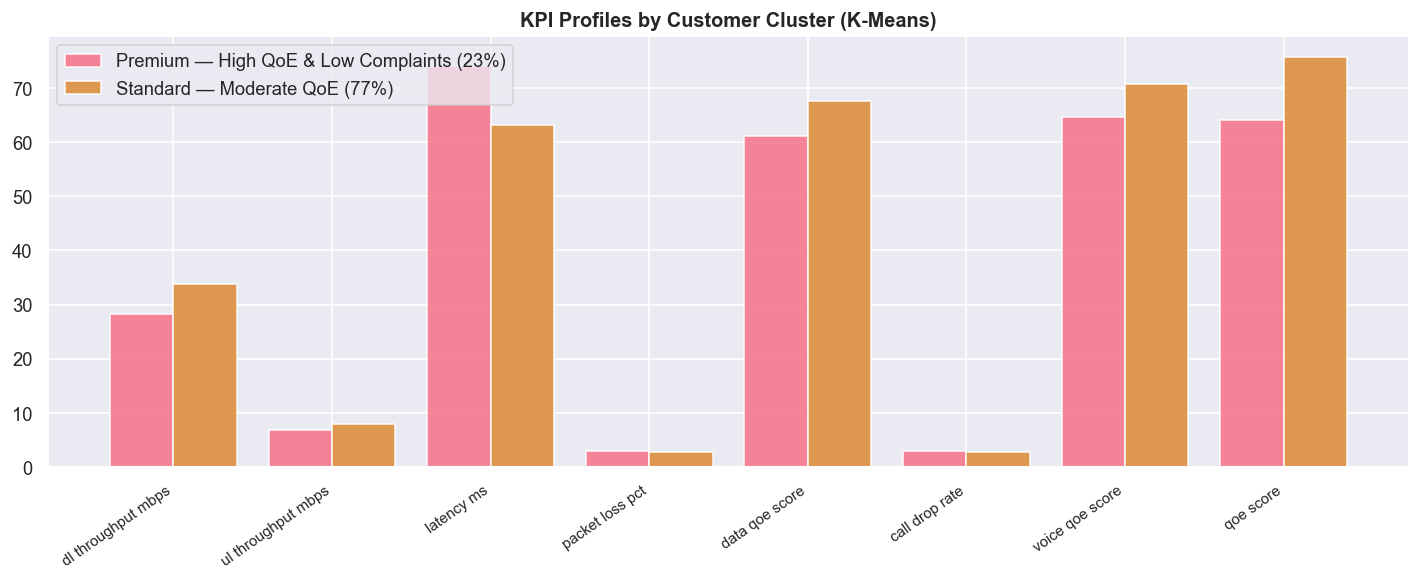


Number of clusters : 2
  Premium — High QoE & Low Complaints            1875 users  (23.4%)
  Standard — Moderate QoE                        6125 users  (76.6%)


In [ ]:
cluster_profiles = cl_results.get("cluster_profiles", {})
profiles         = cluster_profiles.get("kmeans")

if profiles is not None and not profiles.empty:
    print("=== K-MEANS CLUSTER PROFILES ===")
    display(profiles)  # type: ignore[name-defined]

    kpi_profile_cols = [
        c for c in profiles.columns
        if any(k in c for k in ["qoe", "dl_", "latency", "call_drop",
                                  "throughput", "packet", "complaint"])
    ]
    if not kpi_profile_cols:
        kpi_profile_cols = [
            c for c in profiles.select_dtypes("number").columns
            if c not in ("kmeans_cluster", "n_users", "pct_of_users")
        ]

    if kpi_profile_cols and len(profiles) >= 2:
        fig, ax = plt.subplots(figsize=(12, 5))
        x = np.arange(len(kpi_profile_cols))
        w = 0.8 / len(profiles)
        for i, (_, row) in enumerate(profiles.iterrows()):
            label = row.get("cluster_label", f"Cluster {i}")
            vals  = [float(row.get(c, 0)) for c in kpi_profile_cols]
            ax.bar(
                x + i * w - (len(profiles) - 1) * w / 2, vals, w,
                label=f"{label} ({row.get('pct_of_users', 0):.0f}%)",
                color=COLORS[i % len(COLORS)], alpha=0.85,
            )
        ax.set_xticks(x)
        ax.set_xticklabels(
            [c.replace("_mean", "").replace("_", " ")[:18] for c in kpi_profile_cols],
            rotation=35, ha="right", fontsize=9,
        )
        ax.set_title("KPI Profiles by Customer Cluster (K-Means)", fontweight="bold")
        ax.legend()
        plt.tight_layout()
        plt.savefig(f"{FIGURES}/ml_cluster_profiles.png", dpi=150, bbox_inches="tight")
        plt.show()

        print(f"\nNumber of clusters : {len(profiles)}")
        for _, row in profiles.iterrows():
            print(
                f"  {row.get('cluster_label','?'):<45} "
                f"{row.get('n_users',0):>5} users  "
                f"({row.get('pct_of_users',0):.1f}%)"
            )
else:
    print("Cluster profiles not available.")
    if profiles is not None:
        print(f"  Shape   : {profiles.shape}")
        print(f"  Columns : {list(profiles.columns)}")

## Cell 6 — D4 Summary

In [ ]:
print("=" * 65)
print("  D4 — MACHINE LEARNING — KEY RESULTS")
print("=" * 65)

# Anomaly
m     = ad_results.get("metrics", {})
total = max(m.get("total_records", 1), 1)
n_if  = m.get("if_anomalies",        0)
n_st  = m.get("stat_anomalies",      0)
n_uni = m.get("union_anomalies",     0)
n_con = m.get("consensus_anomalies", 0)

print("\n  1. Anomaly Detection")
print(f"     Isolation Forest  : {n_if} anomalies ({n_if/total:.1%})")
print(f"     Statistical       : {n_st} anomalies ({n_st/total:.1%})")
print(f"     Combined (union)  : {n_uni} anomalies ({n_uni/total:.1%})")
print(f"     Combined (both)   : {n_con} anomalies ({n_con/total:.1%})")

# Spike
print("\n  2. Spike Prediction")
for model_name in ("arima", "prophet", "xgboost"):
    col = f"{model_name}_mae"
    if col in scores.columns:
        mean_mae = scores[col].mean()
        print(f"     {model_name.upper():<10} mean MAE: {mean_mae:.2f}")
n_xgb_w = (scores["winner"] == "xgboost").sum() if "winner" in scores.columns else 0
print(f"     XGBoost wins: {n_xgb_w}/{len(scores)} regions")

# Root Cause
print("\n  3. Root Cause Classification")
best_model = rc_results.get("best_model", "?")
print(f"     Best model : {best_model}")
for name, key in [("Random Forest", "rf_report"), ("XGBoost", "xgb_report")]:
    r = rc_results.get(key, {})
    if r:
        acc  = r.get("accuracy", 0)
        f1   = r.get("f1_macro",  0)
        print(f"     {name:<17} Acc={acc:.3f}  F1-macro={f1:.3f}")
fi = rc_results.get("feature_importance")
if fi is not None and not fi.empty:
    feat_col = next((c for c in fi.columns if "feature" in c.lower()), fi.columns[0])
    imp_col  = fi.select_dtypes("number").columns[0]
    top_f    = fi.sort_values(imp_col, ascending=False).iloc[0]
    print(f"     Top feature : {top_f[feat_col]}")
shap_ok = rc_results.get("shap_values") is not None
print(f"     SHAP values : {'✓ computed' if shap_ok else 'not available (pip install shap)'}")

# Clustering
print("\n  4. Customer Clustering")
print(f"     Optimal K        : {cl_results.get('optimal_k', '?')}")
print(f"     Silhouette score : {km.get('silhouette_score', 0):.3f}")
print(f"     Davies-Bouldin   : {km.get('davies_bouldin', 0):.3f}")
print(f"     PCA variance     : {cl_results.get('pca_variance_pct', 0):.1f}%")
print(f"     DBSCAN clusters  : {db.get('n_clusters','?')}")

print()
print("=" * 65)

  D4 — MACHINE LEARNING — KEY RESULTS

  1. Anomaly Detection
     Isolation Forest  : 345 anomalies (4.3%)
     Statistical       : 913 anomalies (11.3%)
     Combined (union)  : 1231 anomalies (15.2%)
     Combined (both)   : 27 anomalies (0.3%)

  2. Spike Prediction
     ARIMA      mean MAE: 1.55
     PROPHET    mean MAE: 2.02
     XGBOOST    mean MAE: 1.04
     XGBoost wins: 20/24 regions

  3. Root Cause Classification
     Best model : xgboost
     Random Forest     Acc=0.485  F1-macro=0.352
     XGBoost           Acc=0.465  F1-macro=0.370
     Top feature : data_session_success_rate_mean
     SHAP values : ✓ computed

  4. Customer Clustering
     Optimal K        : 2
     Silhouette score : 0.209
     Davies-Bouldin   : 1.887
     PCA variance     : 37.7%
     DBSCAN clusters  : 1



## Cell 7 — D4 Checklist
FIX N8: consistent pass/fail checklist matching Notebooks 01–04.

In [ ]:
def _fig_exists(name: str) -> bool:
    return Path(f"{FIGURES}/{name}").exists()

def _model_exists(subdir: str, name: str) -> bool:
    return Path(f"models/{subdir}/{name}").exists()

checklist = [
    # Anomaly
    ("Isolation Forest trained",         _model_exists("anomaly", "isolation_forest.pkl")),
    ("Anomaly timeline chart saved",     _fig_exists("ml_anomaly_timeline.png")),
    ("Anomaly heatmap saved",            _fig_exists("ml_anomaly_heatmap.png")),
    # Spike
    ("Spike predictions computed",       not sp_results["forecasts"].empty),
    ("Spike comparison chart saved",     _fig_exists("ml_spike_model_comparison.png")),
    ("Spike forecast chart saved",       _fig_exists("ml_spike_forecast.png")),
    # Root Cause
    ("Random Forest trained",            _model_exists("classification", "random_forest.pkl")),
    ("XGBoost classifier trained",       _model_exists("classification", "xgboost_classifier.pkl")),
    ("Confusion matrices saved",         _fig_exists("ml_rootcause_confusion.png")),
    ("Feature importance chart saved",   _fig_exists("ml_rootcause_importance.png")),
    ("SHAP summary plot saved",          _fig_exists("ml_shap_summary.png")),
    # Clustering
    ("K-Means model trained",            _model_exists("clustering", "kmeans.pkl")),
    ("DBSCAN model trained",             _model_exists("clustering", "dbscan.pkl")),
    ("Elbow/silhouette chart saved",     _fig_exists("ml_clustering_elbow.png")),
    ("PCA scatter plot saved",           _fig_exists("ml_clustering_pca.png")),
    ("Cluster profiles chart saved",     _fig_exists("ml_cluster_profiles.png")),
]

print("=" * 65)
print("  DELIVERABLE D4 — CHECKLIST")
print("=" * 65)

all_pass = True
for description, condition in checklist:
    status = "✓" if condition else "✗"
    if not condition:
        all_pass = False
    print(f"  [{status}] {description}")

print("=" * 65)
if all_pass:
    print("  D4 COMPLETE — all checks passed ✓")
    print("  → Next: Notebook 06 — NOC Dashboard")
else:
    print("  D4 INCOMPLETE — review failed checks above ✗")
print("=" * 65)

  DELIVERABLE D4 — CHECKLIST
  [✓] Isolation Forest trained
  [✓] Anomaly timeline chart saved
  [✓] Anomaly heatmap saved
  [✓] Spike predictions computed
  [✓] Spike comparison chart saved
  [✓] Spike forecast chart saved
  [✓] Random Forest trained
  [✓] XGBoost classifier trained
  [✓] Confusion matrices saved
  [✓] Feature importance chart saved
  [✓] SHAP summary plot saved
  [✓] K-Means model trained
  [✓] DBSCAN model trained
  [✓] Elbow/silhouette chart saved
  [✓] PCA scatter plot saved
  [✓] Cluster profiles chart saved
  D4 COMPLETE — all checks passed ✓
  → Next: Notebook 06 — NOC Dashboard
